# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [2]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


## 1. Ingest and clean the input text corpus string and initialize a standard text tokenization instance to map words to integers.


In [3]:
import re

corpus = '''
data science combines statistics and machine learning
python is widely used for data analysis
pandas helps manipulate structured datasets
numpy provides efficient numerical computations
data visualization makes insights easier to understand
machine learning models learn patterns from historical data
'''

corpus = corpus.lower()                      # Convert to lowercase
corpus = re.sub(r'[^a-z\s]', '', corpus)     # Remove punctuation/special characters
corpus = re.sub(r'\s+', ' ', corpus).strip() # Remove extra spaces

print("Cleaned Corpus:")
print(corpus)

tokenizer = Tokenizer()

# Learn the vocabulary
tokenizer.fit_on_texts([corpus])

word_index = tokenizer.word_index

print("\nWord to Integer Mapping:")
print(word_index)

print("\nVocabulary Size:", len(word_index) + 1)

Cleaned Corpus:
data science combines statistics and machine learning python is widely used for data analysis pandas helps manipulate structured datasets numpy provides efficient numerical computations data visualization makes insights easier to understand machine learning models learn patterns from historical data

Word to Integer Mapping:
{'data': 1, 'machine': 2, 'learning': 3, 'science': 4, 'combines': 5, 'statistics': 6, 'and': 7, 'python': 8, 'is': 9, 'widely': 10, 'used': 11, 'for': 12, 'analysis': 13, 'pandas': 14, 'helps': 15, 'manipulate': 16, 'structured': 17, 'datasets': 18, 'numpy': 19, 'provides': 20, 'efficient': 21, 'numerical': 22, 'computations': 23, 'visualization': 24, 'makes': 25, 'insights': 26, 'easier': 27, 'to': 28, 'understand': 29, 'models': 30, 'learn': 31, 'patterns': 32, 'from': 33, 'historical': 34}

Vocabulary Size: 35


## 2. Reframe word index tracking lists into progressive sliding-window combinations (n-grams) and match vector dimensions using pad_sequences.

In [4]:
# Store all n-gram sequences
input_sequences = []

# Generate n-grams for each sentence
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]

    for i in range(1, len(token_list)):
        n_gram = token_list[:i+1]
        input_sequences.append(n_gram)

# Find the longest sequence
max_sequence_len = max(len(seq) for seq in input_sequences)

# Pad all sequences with zeros at the beginning
input_sequences = pad_sequences(input_sequences,maxlen=max_sequence_len,padding='pre')

print("Maximum Sequence Length:", max_sequence_len)
print("\nPadded Input Sequences:")
print(input_sequences)

Maximum Sequence Length: 39

Padded Input Sequences:
[[ 0  0  0 ...  0  1  4]
 [ 0  0  0 ...  1  4  5]
 [ 0  0  0 ...  4  5  6]
 ...
 [ 0  0  1 ... 31 32 33]
 [ 0  1  4 ... 32 33 34]
 [ 1  4  5 ... 33 34  1]]


## 3. Build three separate text sequence models: Vanilla SimpleRNN, gated LSTM, and optimized GRU.

In [5]:
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

# Split into X and y
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

# Vocabulary size
total_words = len(tokenizer.word_index) + 1

# One-hot encode the output
y = to_categorical(y, num_classes=total_words)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (38, 38)
y shape: (38, 35)


### Vanilla SimpleRNN

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=64,
              input_length=max_sequence_len-1),

    SimpleRNN(100),

    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Gated LSTM

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=64,
              input_length=max_sequence_len-1),

    LSTM(100),

    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Optimized GRU

In [8]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense

gru_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=64,
              input_length=max_sequence_len-1),

    GRU(128),

    Dropout(0.2),

    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 4. Train all three variations over 200 epochs using an identical optimizer configuration.

In [11]:
# Train SimpleRNN
history_rnn = rnn_model.fit(X,y,epochs=200,verbose=1)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0188
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 1.0000 - loss: 0.0186
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 1.0000 - loss: 0.0185 
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.0183
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0181 
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 1.0000 - loss: 0.0179
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0178
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.0176 
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.0174
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.0173
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 1.0000 - loss: 0.0172
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 -

In [12]:
history_lstm = lstm_model.fit(X,y,epochs=200,verbose=1)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.3137
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.3073
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.3054 
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 1.0000 - loss: 0.2992
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 1.0000 - loss: 0.2961
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.2907
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.2849
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.2795
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.2763
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.2749
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.2704
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - l

In [13]:
history_gru = gru_model.fit(X,y,epochs=200,verbose=1)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0422
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 1.0000 - loss: 0.0512
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0525 
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0462
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 1.0000 - loss: 0.0400
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0468
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0411
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 1.0000 - loss: 0.0426
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0451
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 1.0000 - loss: 0.0431
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 1.0000 - loss: 0.0410
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 1.0000 - l

## 5. Map optimization trajectories on a line plot to evaluate training stabilization speeds across models.

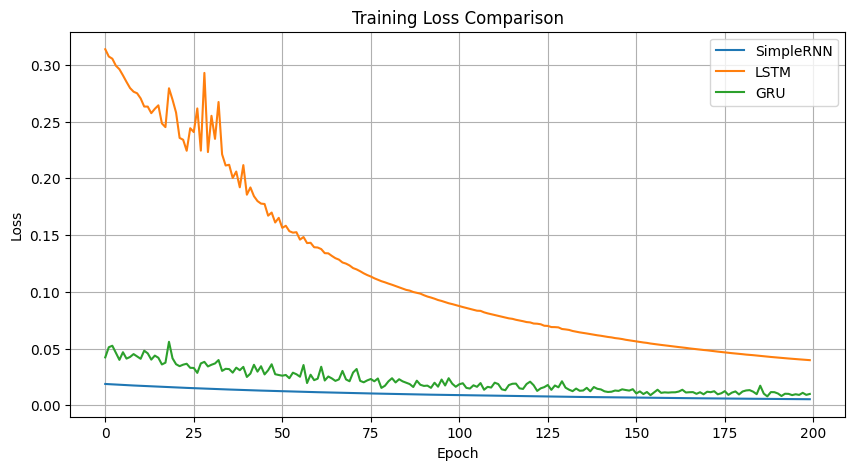

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(history_rnn.history['loss'], label='SimpleRNN')
plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_gru.history['loss'], label='GRU')

plt.title('Training Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

## 6. Program the internal selection logic inside generate_text using np.argmax over next-word probability arrays.

In [15]:
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def generate_text(model, seed_text, next_words):
    """
    Generate text using a trained RNN/LSTM/GRU model.

    Parameters:
        model       : Trained model
        seed_text   : Starting text
        next_words  : Number of words to generate
    """

    for _ in range(next_words):

        # Convert seed text into token sequence
        token_list = tokenizer.texts_to_sequences([seed_text])[0]

        # Pad sequence to match training input size
        token_list = pad_sequences([token_list],maxlen=max_sequence_len-1,padding='pre')

        # Predict probability of every word
        predicted_probs = model.predict(token_list, verbose=0)

        # Select the word with highest probability
        predicted_index = np.argmax(predicted_probs, axis=-1)[0]

        # Convert predicted index back to word
        output_word = ""

        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        # Append predicted word
        seed_text += " " + output_word

    return seed_text

In [16]:
print("SimpleRNN:")
print(generate_text(rnn_model, "data science", 5))

print("\nLSTM:")
print(generate_text(lstm_model, "data science", 5))

print("\nGRU:")
print(generate_text(gru_model, "data science", 5))

SimpleRNN:
data science combines statistics and machine learning

LSTM:
data science combines statistics and machine learning

GRU:
data science combines statistics and machine learning


## 7. Complete the student learning tasks: replace the boilerplate text with a custom paragraph corpus; upscale embedding dimensions; expand training to 200 epochs; widen hidden layers (64-->128); and adjust output to return 10 words per generation prompt.

In [17]:
corpus = '''
data science is transforming industries by extracting valuable insights from data.
machine learning algorithms learn patterns from historical information to make predictions.
python is one of the most popular programming languages for data analysis and artificial intelligence.
libraries such as numpy pandas and tensorflow simplify numerical computation data processing and deep learning.
neural networks are capable of solving complex problems including image classification natural language processing and recommendation systems.
continuous learning and experimentation help data scientists build accurate and reliable predictive models.
'''

### Increase the embedding dimension

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

rnn_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=128,
              input_length=max_sequence_len-1),

    SimpleRNN(128),

    Dense(total_words, activation='softmax')
])

rnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_2 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

lstm_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=128,
              input_length=max_sequence_len-1),

    LSTM(128),

    Dense(total_words, activation='softmax')
])

lstm_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GRU, Dropout, Dense

gru_model = Sequential([
    Embedding(input_dim=total_words,
              output_dim=128,
              input_length=max_sequence_len-1),

    GRU(128),

    Dropout(0.2),

    Dense(total_words, activation='softmax')
])

gru_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

gru_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### Generate 10 words instead of 5

In [24]:
print("SimpleRNN:")
print(generate_text(rnn_model, "data science", 10))

print("\nLSTM:")
print(generate_text(lstm_model, "data science", 10))

print("\nGRU:")
print(generate_text(gru_model, "data science", 10))

SimpleRNN:
data science helps structured and insights computations combines to patterns for helps

LSTM:
data science datasets datasets datasets visualization datasets visualization numpy datasets datasets visualization

GRU:
data science learning         


# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**